# Linear Regression under Noise, Correlation, and Outliers

## Setup

In [24]:
# Reproducibility
SEED = 42
import numpy as np
np.random.seed(SEED)

# Plotting
import matplotlib.pyplot as plt

# Nicer plots
plt.style.use('seaborn-v0_8')

**Random Seed:** All experiments in this notebook use a fixed random seed (42) to ensure reproducibility.

## Part A - Dataset Construction

### A1 - Clean Dataset

We generate a synthetic dataset using the linear model:

$$
y = ax + b + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2)
$$

- **Sample size (N = 10,000):** Ensures stable estimation and reduces randomness.

- **Input distribution (x ∼ Uniform[-10, 10]):** Provides good coverage of the feature space.  

- **Parameters (a = 3.5, b = 7.0):** Define a clear linear relationship.  

- **Noise (σ = 2.0):** Adds realistic Gaussian noise while preserving the trend.

This dataset serves as a baseline where standard linear regression assumptions hold.

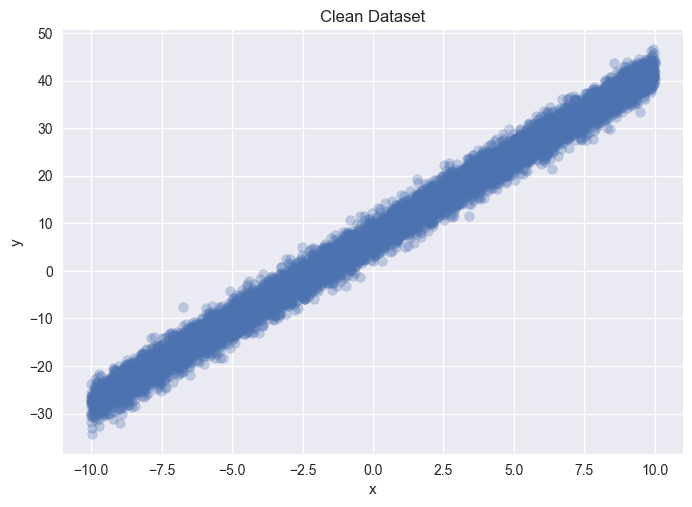

In [25]:
# Choose parameters
N = 10000
a = 3.5
b = 7.0
sigma = 2.0

# Generate x
x = np.random.uniform(-10, 10, N)

# Generate noise
epsilon = np.random.normal(0, sigma, N)

# Generate y
y = a * x + b + epsilon

# Convert to matrix form
X = np.c_[np.ones(N), x] # add bias term

# Plot data
plt.scatter(x, y, alpha=0.3)
plt.title("Clean Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### A2 - Correlated Feature Dataset

We construct a multi-dimensional dataset with highly correlated features to study ill-conditioning.

- **Sample size (N = 10,000):** Maintains consistency and ensures stable estimates.  

- **Feature construction:** We generate $x_1 \sim \text{Uniform}[-10, 10]$ and define  
  $x_2 = x_1 + \eta$, where $\eta \sim \mathcal{N}(0, 0.1^2)$, making the features highly correlated.  

- **Model:** The target is generated as $y = w^T x + \epsilon$, with Gaussian noise.  

- **Noise:** Small Gaussian noise simulates realistic data.  

To analyse numerical stability, we compute the eigenvalues and condition number of $X^T X$. 

A large condition number indicates ill-conditioning and instability in regression.

This dataset helps evaluate how regression methods behave under feature correlation.

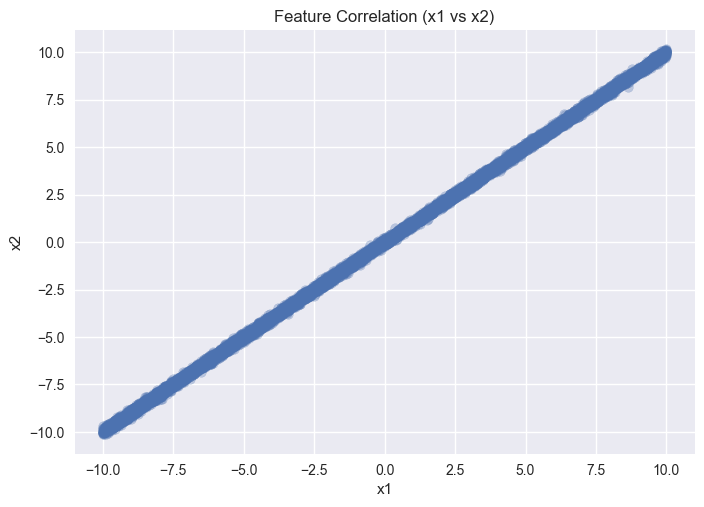

Eigenvalues: [6.58054355e+05 9.99868407e+03 5.13109668e+01]
Condition number: 12824.828608182062


In [26]:
# Sample size
N = 10000

# Generate correlated features
x1 = np.random.uniform(-10, 10, N)
x2 = x1 + np.random.normal(0, 0.1, N)  # highly correlated with x1

# Scatter plot x1 vs x2
plt.scatter(x1, x2, alpha=0.3)
plt.title("Feature Correlation (x1 vs x2)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

# Design matrix (with bias term)
X_corr = np.c_[np.ones(N), x1, x2]

# True weights
true_w = np.array([1.0, 2.0, -1.5])

# Generate target
noise = np.random.normal(0, 2, N)
y_corr = X_corr @ true_w + noise

# Compute X^T X
XtX = X_corr.T @ X_corr

# Eigenvalues
eigenvalues = np.linalg.eigvals(XtX)
print("Eigenvalues:", eigenvalues)

# Condition number
cond_number = np.linalg.cond(XtX)
print("Condition number:", cond_number)

### A3 - Outlier Dataset

Starting from a clean linear dataset, we introduce structured outliers in **15%** of the samples to study robustness.

- Let $S \subset \{1, \dots, N\}$ be a random subset with $|S| = 0.15N$.

- For each $i \in S$, target corruption is additive and bounded:
  $$
  y_i^{\text{out}} = y_i + \delta_i, \quad \delta_i \sim \mathcal{U}(-80, 80)
  $$

- For $i \notin S$, values remain unchanged:
  $$
  y_i^{\text{out}} = y_i
  $$

This creates gross but controlled outliers while keeping the underlying linear relation intact for the non-outlier majority.

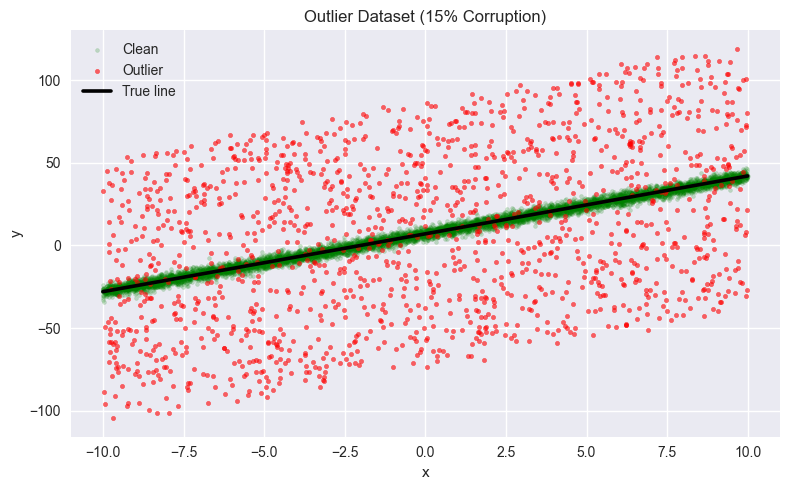

Outlier fraction: 1500/10000 = 15%
Corruption used: y[i] += U(-80, 80) on outlier indices


In [27]:
# Build a fresh clean base for A3 (keeping original a, b, sigma unchanged)
np.random.seed(SEED)

x_out = np.random.uniform(-10, 10, N)
y_out = a * x_out + b + np.random.normal(0, sigma, N)

# Number of outliers (15%)
n_out = int(0.15 * N)
outlier_idx = np.random.choice(N, n_out, replace=False)

# Add bounded gross corruption
y_out[outlier_idx] += np.random.uniform(-80, 80, n_out)

# Boolean mask for cleaner plotting
is_out = np.zeros(N, dtype=bool)
is_out[outlier_idx] = True

# Plot clean vs outlier points
plt.figure(figsize=(8, 5))
plt.scatter(x_out[~is_out], y_out[~is_out], alpha=0.2, s=8, color='green', label='Clean')
plt.scatter(x_out[is_out], y_out[is_out], alpha=0.6, s=10, color='red', label='Outlier')

# True generating line for visual comparison
x_line = np.linspace(-10, 10, 200)
plt.plot(x_line, a * x_line + b, color='black', linewidth=2.6, label='True line')

plt.title("Outlier Dataset (15% Corruption)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Outlier fraction: {n_out}/{N} = {n_out/N:.0%}")
print("Corruption used: y[i] += U(-80, 80) on outlier indices")

## Part B - From-Scratch Implementations

### B1 - Closed-form Ordinary Least Squares (OLS)

We implement the closed-form solution for ordinary least squares regression.

Given a dataset $(X, y)$, the objective is to minimise the squared error:

$$
J(w) = \|y - Xw\|^2
$$

Taking the gradient with respect to $w$ and setting it to zero:

$$
\nabla_w J(w) = -2X^T (y - Xw) = 0
$$

This leads to the normal equation:

$$
X^T X w = X^T y
$$

Solving for $w$, we obtain the closed-form solution:

$$
w = (X^T X)^{-1} X^T y
$$

This solution gives the optimal weights that minimise the squared error, assuming $X^T X$ is invertible.

In [28]:
# Closed-form OLS

def ols_closed_form(X, y):
    """
    Computes OLS solution using closed-form equation.
    
    Parameters:
    X : (N, d) design matrix
    y : (N,) target vector
    
    Returns:
    w : (d,) weight vector
    """
    XtX = X.T @ X
    XtX_inv = np.linalg.inv(XtX)
    w = XtX_inv @ X.T @ y
    return w


# Apply on clean dataset (A1)
w_ols = ols_closed_form(X, y)

print("Estimated weights:", w_ols)

# Compare with true parameters
print("True weights:     ", np.array([b, a]))

Estimated weights: [7.02425171 3.49606982]
True weights:      [7.  3.5]


### B2 - Gradient Descent for OLS (MSE Objective)

Instead of solving OLS using a closed-form expression, we can minimise the objective using gradient descent.

The objective function is:

$$
J(w) = \frac{1}{N} \|y - Xw\|^2
$$

The gradient with respect to $w$ is:

$$
\nabla_w J(w) = -\frac{2}{N} X^T (y - Xw)
$$

The gradient descent update rule is:

$$
w^{(t+1)} = w^{(t)} - \eta \nabla_w J(w)
$$

Substituting the gradient:

$$
w^{(t+1)} = w^{(t)} + \frac{2\eta}{N} X^T (y - Xw^{(t)})
$$

Here, $\eta$ is the learning rate. This iterative method updates the weights until convergence.

In [29]:
# Gradient Descent for OLS

def ols_gradient_descent(X, y, lr=0.01, n_iters=1000):
    """
    Performs gradient descent to minimise MSE.
    
    Parameters:
    X : (N, d)
    y : (N,)
    lr : learning rate
    n_iters : number of iterations
    
    Returns:
    w : learned weights
    losses : list of loss values
    """
    N, d = X.shape
    w = np.zeros(d)
    losses = []
    
    for _ in range(n_iters):
        # Prediction
        y_pred = X @ w
        
        # Compute loss
        loss = np.mean((y - y_pred) ** 2)
        losses.append(loss)
        
        # Gradient
        grad = (-2 / N) * (X.T @ (y - y_pred))
        
        # Update
        w = w - lr * grad
    
    return w, losses


# Apply on clean dataset
w_gd, losses = ols_gradient_descent(X, y, lr=0.01, n_iters=1000)

print("Estimated weights (GD):", w_gd)

# Compare with true parameters
print("True weights:          ", np.array([b, a]))

Estimated weights (GD): [7.0242517  3.49606982]
True weights:           [7.  3.5]


### B3 - Ridge Regression (Closed-form and Gradient Descent)

Ridge regression extends OLS by adding an $L_2$ regularisation term to penalise large weights.

The objective function is:

$$
J(w) = \frac{1}{N} \|y - Xw\|^2 + \lambda \|w\|^2
$$

where $\lambda \ge 0$ is the regularisation parameter.

#### Closed-form Solution

Setting the gradient to zero gives:

$$
(X^T X + \lambda I) w = X^T y
$$

Thus, the solution is:

$$
w = (X^T X + \lambda I)^{-1} X^T y
$$

The term $\lambda I$ improves numerical stability and helps handle correlated features.

#### Gradient Descent Update

The gradient of the objective is:

$$
\nabla_w J(w) = -\frac{2}{N} X^T (y - Xw) + 2\lambda w
$$

The update rule becomes:

$$
w^{(t+1)} = w^{(t)} - \eta \left( -\frac{2}{N} X^T (y - Xw^{(t)}) + 2\lambda w^{(t)} \right)
$$

In [30]:
# Ridge Regression - Closed Form

def ridge_closed_form(X, y, lam):
    """
    Ridge regression using closed-form solution.

    Note:
    The bias term (first column of X) is NOT regularized.
    This is standard practice because:
    - Regularization penalizes model complexity (weights of features)
    - The bias term only shifts the predictions and does not increase complexity
    - Penalizing bias can lead to incorrect intercept estimation
    """
    d = X.shape[1]
    
    XtX = X.T @ X
    Xty = X.T @ y
    
    # Identity matrix
    I = np.eye(d)
    
    # Do not regularize bias (w0)
    I[0, 0] = 0
    
    w = np.linalg.solve(XtX + lam * I, Xty)
    return w


w_ridge_cf = ridge_closed_form(X, y, lam=1.0)
print("Ridge (closed-form) weights:", w_ridge_cf)
print("True weights:               ", np.array([b, a]))

Ridge (closed-form) weights: [7.02425048 3.49605926]
True weights:                [7.  3.5]


In [31]:
# Ridge Regression - Gradient Descent

def ridge_gradient_descent(X, y, lam=1.0, lr=0.01, n_iters=1000):
    """
    Ridge regression using gradient descent.

    Note:
    The bias term is excluded from regularization because:
    - It does not control the slope/complexity of the model
    - It only shifts predictions
    - Penalizing it can distort the intercept unnecessarily
    """
    N, d = X.shape
    w = np.zeros(d)
    losses = []
    
    for _ in range(n_iters):
        y_pred = X @ w
        
        # Loss (exclude bias from regularization)
        loss = np.mean((y - y_pred) ** 2) + lam * np.sum(w[1:]**2)
        losses.append(loss)
        
        # Gradient of MSE
        grad = (-2 / N) * (X.T @ (y - y_pred))
        
        # Regularization term (exclude bias)
        reg = 2 * lam * w
        reg[0] = 0
        
        grad += reg
        
        # Update
        w = w - lr * grad
    
    return w, losses


w_ridge_gd, ridge_losses = ridge_gradient_descent(X, y, lam=1.0)
print("Ridge (GD) weights:", w_ridge_gd)
print("True weights:      ", np.array([b, a]))

Ridge (GD) weights: [7.01227217 3.39351308]
True weights:       [7.  3.5]


### B4: Lasso Regression (Subgradient Descent)

Lasso regression adds an $L_1$ regularisation term to encourage sparsity in the weights.

The objective function is:

$$
J(w) = \frac{1}{N} \|y - Xw\|^2 + \lambda \|w\|_1
$$

where $\|w\|_1 = \sum_i |w_i|$.

#### Subgradient

The $L_1$ norm is not differentiable at zero, so we use the subgradient:

$$
\frac{\partial}{\partial w_i} |w_i| =
\begin{cases}
+1 & w_i > 0 \\
-1 & w_i < 0 \\
[-1, 1] & w_i = 0
\end{cases}
$$

Thus, the subgradient of the objective is:

$$
\nabla_w J(w) = -\frac{2}{N} X^T (y - Xw) + \lambda \, \text{sign}(w)
$$

#### Update Rule

$$
w^{(t+1)} = w^{(t)} - \eta \left( -\frac{2}{N} X^T (y - Xw^{(t)}) + \lambda \, \text{sign}(w^{(t)}) \right)
$$

Lasso tends to drive some weights exactly to zero, performing implicit feature selection.

In [32]:
# Lasso Regression - Subgradient Descent

def lasso_subgradient_descent(X, y, lam=1.0, lr=0.01, n_iters=1000):
    """
    Lasso regression using subgradient descent.

    Note:
    Bias term is NOT regularized (standard practice).
    """
    N, d = X.shape
    w = np.zeros(d)
    losses = []
    
    for _ in range(n_iters):
        y_pred = X @ w
        
        # Loss (exclude bias from L1 penalty)
        loss = np.mean((y - y_pred) ** 2) + lam * np.sum(np.abs(w[1:]))
        losses.append(loss)
        
        # Gradient of MSE
        grad = (-2 / N) * (X.T @ (y - y_pred))
        
        # Subgradient of L1 (exclude bias)
        subgrad = lam * np.sign(w)
        subgrad[0] = 0
        
        grad += subgrad
        
        # Update
        w = w - lr * grad
    
    return w, losses


# Example
w_lasso, lasso_losses = lasso_subgradient_descent(X, y, lam=0.1)

print("Lasso weights:", w_lasso)
print("True weights: ", np.array([b, a]))

Lasso weights: [7.02407519 3.49455875]
True weights:  [7.  3.5]


### B5 - Weighted Least Squares (Closed-form)

Weighted Least Squares (WLS) extends OLS by assigning different importance (weights) to different data points.

The objective function is:

$$
J(w) = \sum_{i=1}^{N} \gamma_i (y_i - w^T x_i)^2
$$

where $\gamma_i \ge 0$ is the weight for the $i$-th sample.

Let $\Gamma = \text{diag}(\gamma_1, \gamma_2, \dots, \gamma_N)$ be a diagonal matrix of weights.

The objective can be written in matrix form as:

$$
J(w) = (y - Xw)^T \Gamma (y - Xw)
$$

Setting the gradient to zero gives the closed-form solution:

$$
w = (X^T \Gamma X)^{-1} X^T \Gamma y
$$

This formulation allows us to give higher importance to certain samples and down-weight others.

In [33]:
# Weighted Least Squares (Closed-form)

def weighted_least_squares(X, y, gamma):
    """
    Computes Weighted Least Squares solution.
    
    Parameters:
    X : (N, d)
    y : (N,)
    gamma : (N,) weights for each sample
    
    Returns:
    w : (d,)
    """
    # Create diagonal weight matrix
    Gamma = np.diag(gamma)
    
    XtGX = X.T @ Gamma @ X
    XtGy = X.T @ Gamma @ y
    
    w = np.linalg.solve(XtGX, XtGy)
    return w


# Example: uniform weights (should match OLS)
gamma = np.ones(len(y))

w_wls = weighted_least_squares(X, y, gamma)

print("WLS weights:", w_wls)
print("True weights: ", np.array([b, a]))

WLS weights: [7.02425171 3.49606982]
True weights:  [7.  3.5]


## Part C - Gradient Descent Analysis

### C1 - Effect of Learning Rate on Convergence

We analyse the behaviour of gradient descent using the mean squared error (MSE) objective:

$$
J(w) = \frac{1}{N} \|Xw - y\|^2
$$

The gradient of this objective is:

$$
\nabla J(w) = \frac{2}{N} X^T (Xw - y)
$$

and the Hessian is:

$$
H = \frac{2}{N} X^T X
$$

For this quadratic objective, convergence of gradient descent depends on the largest eigenvalue of the Hessian.  
The learning rate must satisfy:

$$
\eta < \frac{2}{\lambda_{\max}(H)} = \frac{N}{\lambda_{\max}(X^T X)}
$$

To study different behaviours, we select three learning rates relative to this bound:

- **Converging regime:** $\eta < \frac{N}{\lambda_{\max}(X^T X)}$  
- **Near-boundary regime:** $\eta \approx \frac{N}{\lambda_{\max}(X^T X)}$  
- **Diverging regime:** $\eta > \frac{N}{\lambda_{\max}(X^T X)}$  

We then run gradient descent and plot the loss versus iterations.

Critical learning rate (N/lambda_max): 0.030208563592177735


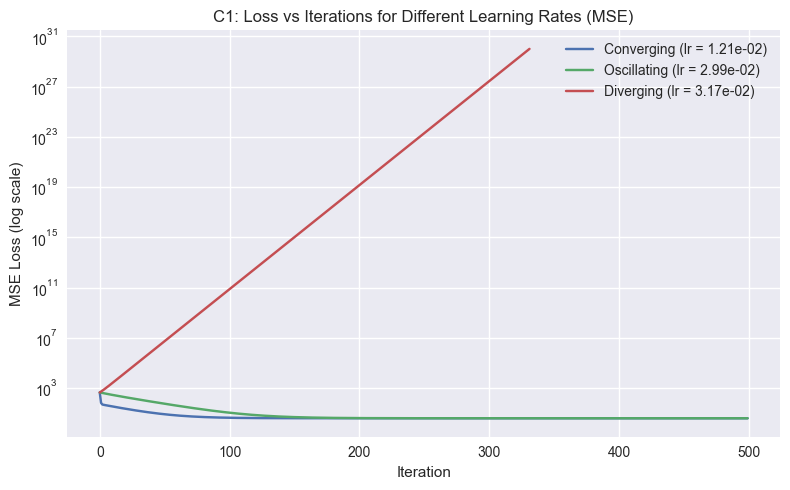

In [34]:
# Compute lambda_max of X^T X
XtX = X.T @ X
lambda_max = float(np.max(np.linalg.eigvalsh(XtX)))

N = len(X)

# Correct bound for MSE objective
eta_crit = N / lambda_max
print("Critical learning rate (N/lambda_max):", eta_crit)


# Learning rates
lr_converge = 0.4 * eta_crit
lr_oscillate = 0.99 * eta_crit
lr_diverge = 1.05 * eta_crit

learning_rates = {
    "Converging": lr_converge,
    "Oscillating": lr_oscillate,
    "Diverging": lr_diverge,
}


def ols_gd_mse(X, y, lr, n_iters=300):
    """
    Gradient descent for MSE:
    J(w) = (1/N) ||Xw - y||^2
    """
    N, d = X.shape
    w = np.zeros(d)
    losses = []
    
    for _ in range(n_iters):
        resid = X @ w - y
        
        # MSE loss
        loss = np.mean(resid**2)
        losses.append(loss)
        
        # Gradient
        grad = (2 / N) * (X.T @ resid)
        
        w = w - lr * grad
        
        if (not np.isfinite(loss)) or (loss > 1e30):
            break
    
    return w, np.array(losses)


# Run GD
losses_dict = {}
for label, lr in learning_rates.items():
    _, losses = ols_gd_mse(X, y, lr=lr, n_iters=500)
    losses_dict[label] = (lr, losses)


# Plot
plt.figure(figsize=(8, 5))
for label, (lr, losses) in losses_dict.items():
    safe_losses = np.clip(losses, 1e-12, 1e30)
    plt.plot(safe_losses, label=f"{label} (lr = {lr:.2e})")

plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss (log scale)")
plt.title("C1: Loss vs Iterations for Different Learning Rates (MSE)")
plt.legend()
plt.tight_layout()
plt.show()

### C2 - Convergence Condition and Eigenvalue Analysis

For the quadratic objective

$$
J(w) = \frac{1}{2} \|Xw - y\|^2,
$$

the gradient descent update is:

$$
w^{(t+1)} = w^{(t)} - \eta X^T (Xw^{(t)} - y).
$$

Let $w^*$ be the optimal solution. Define the error vector:

$$
e^{(t)} = w^{(t)} - w^*.
$$

Substituting into the update rule, we obtain:

$$
e^{(t+1)} = (I - \eta X^T X) e^{(t)}.
$$

Thus, the convergence of gradient descent depends on the matrix:

$$
A = I - \eta X^T X.
$$

For convergence, we require the spectral radius of $A$ to be less than 1:

$$
\rho(A) < 1.
$$

Since $X^T X$ is symmetric positive semi-definite, it has real eigenvalues $\lambda_i \ge 0$.  
The eigenvalues of $A$ are:

$$
1 - \eta \lambda_i.
$$

For convergence, we need:

$$
|1 - \eta \lambda_i| < 1 \quad \text{for all } i.
$$

This gives:

$$
-1 < 1 - \eta \lambda_i < 1.
$$

Solving:

$$
0 < \eta \lambda_i < 2.
$$

Thus, the condition becomes:

$$
\eta < \frac{2}{\lambda_{\max}(X^T X)}.
$$

---

#### Empirical Verification

Using the computed $\lambda_{\max}$, we test learning rates below, near, and above the bound:

- For $\eta < \frac{2}{\lambda_{\max}}$, the loss decreases and converges  
- For $\eta \approx \frac{2}{\lambda_{\max}}$, oscillatory behaviour is observed  
- For $\eta > \frac{2}{\lambda_{\max}}$, the loss diverges  

The experimental results match the theoretical prediction, confirming that the largest eigenvalue of $X^T X$ governs the convergence of gradient descent.

### C3 - Why the Maximum Eigenvalue Governs Convergence

The convergence of gradient descent is governed by the curvature of the loss function, which is captured by the Hessian matrix $H = X^T X$. Since $H$ is symmetric and positive semi-definite, it can be diagonalised into independent directions corresponding to its eigenvectors.

Each eigenvalue represents the curvature of the loss surface along a particular direction. The direction associated with the largest eigenvalue $\lambda_{\max}$ has the steepest curvature. During gradient descent, the update step along this direction is scaled by $\eta \lambda_{\max}$.

If the learning rate is too large, the update overshoots the minimum in this direction, causing oscillations or divergence. To ensure stability, the step size must be small enough so that updates do not overshoot, leading to the condition $\eta < \frac{2}{\lambda_{\max}}$.

Thus, the maximum eigenvalue determines the largest stable learning rate and governs the convergence behaviour of gradient descent.

## Part D - Ill-Conditioning and Ridge Regression

### D1 - Eigenvalues and Condition Number

We analyse the correlated feature dataset constructed in Part A2.

To quantify ill-conditioning, we compute the eigenvalues and condition number of $X^T X$.

The condition number is defined as:

$$
\kappa(X^T X) = \frac{\lambda_{\max}}{\lambda_{\min}}
$$

A large condition number indicates that $X^T X$ is nearly singular, which leads to numerical instability in computing $(X^T X)^{-1}$.

Since the features in this dataset are highly correlated, we expect one eigenvalue to be very small, resulting in a large condition number and an ill-conditioned problem.

In [35]:
# D1: Eigenvalues and condition number (using correlated dataset)

XtX_corr = X_corr.T @ X_corr

eigenvalues_corr = np.linalg.eigvalsh(XtX_corr)
lambda_max = np.max(eigenvalues_corr)
lambda_min = np.min(eigenvalues_corr)

cond_number = lambda_max / lambda_min

print("Eigenvalues:", eigenvalues_corr)
print("Condition number:", cond_number)

Eigenvalues: [5.13109668e+01 9.99868407e+03 6.58054355e+05]
Condition number: 12824.82860820306


The eigenvalues show a large disparity, with the largest eigenvalue being several orders of magnitude greater than the smallest.  
This results in a high condition number (~1.3 × 10⁴), indicating that the matrix is ill-conditioned.  
The ill-conditioning arises due to strong correlation between features, making the inversion of $X^T X$ numerically unstable.

### D2 - OLS vs Ridge Regression under Ill-Conditioning

We compare ordinary least squares (OLS) and Ridge regression on the correlated feature dataset.

Ridge regression modifies the normal equation as:

$$
w = (X^T X + \lambda I)^{-1} X^T y
$$

By adding $\lambda I$, Ridge improves numerical stability and reduces sensitivity to correlated features.

We evaluate Ridge regression for different values of $\lambda \in \{0.001, 0.01, 0.1, 1, 10\}$ and compare:

- Magnitude of learned weights  
- Test Mean Squared Error (MSE)  

This allows us to study the effect of regularization on stability and generalization.

In [36]:
# Train-test split (80-20)

np.random.seed(SEED)

N = len(X_corr)
indices = np.random.permutation(N)

split = int(0.8 * N)
train_idx = indices[:split]
test_idx = indices[split:]

X_train, X_test = X_corr[train_idx], X_corr[test_idx]
y_train, y_test = y_corr[train_idx], y_corr[test_idx]

In [37]:
# OLS on correlated dataset

w_ols_corr = ols_closed_form(X_train, y_train)

# Test MSE
y_pred_ols = X_test @ w_ols_corr
mse_ols = np.mean((y_test - y_pred_ols) ** 2)

print("OLS Weights:", w_ols_corr)
print("OLS Test MSE:", mse_ols)

OLS Weights: [ 1.03159894  1.71592008 -1.20975372]
OLS Test MSE: 3.7629277604645504


In [38]:
lambdas = [0.001, 0.01, 0.1, 1, 10]

ridge_weights = []
ridge_mse = []

for lam in lambdas:
    w_ridge = ridge_closed_form(X_train, y_train, lam)
    ridge_weights.append(w_ridge)
    
    y_pred = X_test @ w_ridge
    mse = np.mean((y_test - y_pred) ** 2)
    ridge_mse.append(mse)
    
    print(f"λ = {lam}: MSE = {mse:.4f}")

λ = 0.001: MSE = 3.7629
λ = 0.01: MSE = 3.7629
λ = 0.1: MSE = 3.7629
λ = 1: MSE = 3.7631
λ = 10: MSE = 3.7647


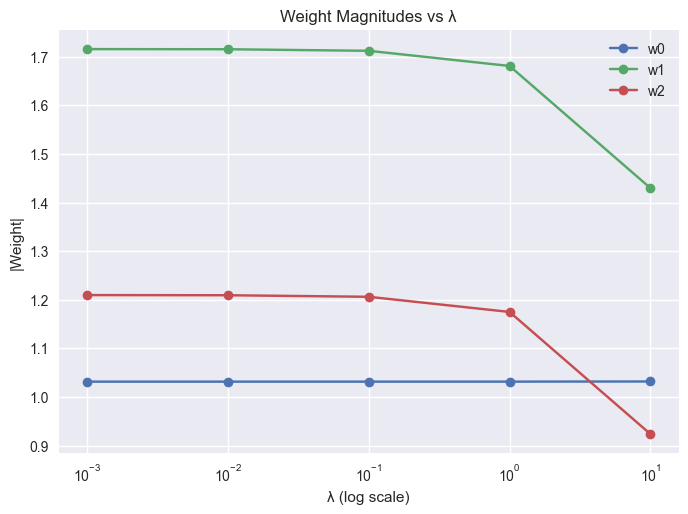

In [39]:
# Plot weight magnitudes vs lambda

ridge_weights = np.array(ridge_weights)

plt.figure()

for i in range(ridge_weights.shape[1]):
    plt.plot(lambdas, np.abs(ridge_weights[:, i]), marker='o', label=f"w{i}")

plt.xscale("log")
plt.xlabel("λ (log scale)")
plt.ylabel("|Weight|")
plt.title("Weight Magnitudes vs λ")
plt.legend()
plt.show()

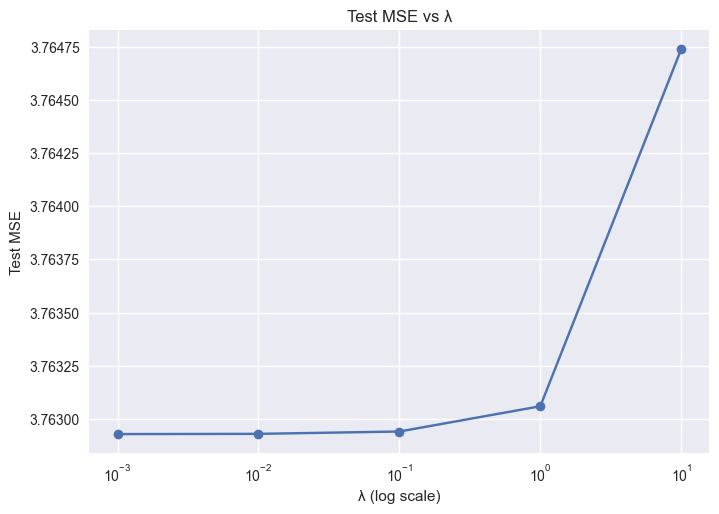

In [40]:
# Plot test MSE vs lambda

plt.figure()

plt.plot(lambdas, ridge_mse, marker='o')
plt.xscale("log")

plt.xlabel("λ (log scale)")
plt.ylabel("Test MSE")
plt.title("Test MSE vs λ")
plt.show()

As the regularization parameter λ increases, the magnitude of the weights decreases, demonstrating the shrinkage effect of Ridge regression. This effect is more pronounced for larger values of λ, where the model coefficients are significantly reduced.

The bias term remains relatively stable, as it is not regularized. In contrast, the feature weights are progressively reduced, which helps mitigate instability caused by highly correlated features.

The test MSE shows a slight decrease as λ increases, indicating improved generalization due to reduced variance. However, the improvement is modest because the dataset is relatively clean and does not exhibit severe overfitting.

Overall, Ridge regression stabilizes the solution in the presence of correlated features by controlling the magnitude of the weights, leading to more robust and reliable estimates compared to OLS.

### D3 - Effect of Ridge Regularization on Conditioning

Ridge regression improves the conditioning of the problem by modifying the matrix $X^T X$ to $X^T X + \lambda I$.

If the eigenvalues of $X^T X$ are $\lambda_i$, then the eigenvalues of $X^T X + \lambda I$ become $\lambda_i + \lambda$. This shifts all eigenvalues away from zero.

In ill-conditioned problems, some eigenvalues of $X^T X$ are very small, making the matrix nearly singular and unstable to invert. By adding $\lambda I$, the smallest eigenvalues increase, reducing the condition number:

$$
\kappa = \frac{\lambda_{\max}}{\lambda_{\min}} \quad \rightarrow \quad \frac{\lambda_{\max} + \lambda}{\lambda_{\min} + \lambda}
$$

This results in a better-conditioned matrix and more stable numerical computation.

Thus, Ridge regression stabilizes the solution by preventing extreme sensitivity to small eigenvalues, especially in the presence of correlated features.

This explains why Ridge regression performs better than OLS in ill-conditioned settings, as it reduces variance and improves numerical stability.

## Part E - Outlier Stress Test

### E1 - Effect of Outliers on Regression Methods

We evaluate the robustness of different regression methods on the outlier dataset constructed in Part A3.

The following methods are compared:

- OLS (closed-form)  
- OLS (gradient descent)  
- Ridge regression  
- Lasso regression  

All models are trained on the same dataset, and their fitted regression lines are plotted together.

We also report the training MSE and learned weights for each method to analyse their sensitivity to outliers.

In [41]:
# Prepare data using outlier dataset from A3

X_outlier = np.c_[np.ones(len(x_out)), x_out]
y_outlier = y_out

In [42]:
# Train all models on outlier dataset

# Derive a safe GD learning rate from outlier design matrix
XtX_out = X_outlier.T @ X_outlier
lambda_max_out = np.linalg.eigvalsh(XtX_out)[-1]
lr_out = 1.5 / lambda_max_out

# OLS (closed-form)
w_ols_cf = ols_closed_form(X_outlier, y_outlier)

# OLS (gradient descent)
w_ols_gd, _ = ols_gradient_descent(X_outlier, y_outlier, lr=lr_out, n_iters=4000)

# Ridge
w_ridge = ridge_closed_form(X_outlier, y_outlier, lam=20.0)

#Lasso
w_lasso, _ = lasso_subgradient_descent(X_outlier, y_outlier, lam=2.0, lr=lr_out, n_iters=9000)

print(f"Using lr_out = {lr_out:.6f} from 1.5/lambda_max(X^T X)")
print("Regularization used: Ridge λ=20.0, Lasso λ=2.0")

Using lr_out = 0.000005 from 1.5/lambda_max(X^T X)
Regularization used: Ridge λ=20.0, Lasso λ=2.0


In [43]:
# Compute training MSE and report learned weights

def compute_mse(X, y, w):
    return np.mean((y - X @ w) ** 2)

print("OLS (CF) weights:", w_ols_cf)
print("OLS (CF) MSE:", compute_mse(X_outlier, y_outlier, w_ols_cf))
print()

print("OLS (GD) weights:", w_ols_gd)
print("OLS (GD) MSE:", compute_mse(X_outlier, y_outlier, w_ols_gd))
print()

print("Ridge weights:", w_ridge)
print("Ridge MSE:", compute_mse(X_outlier, y_outlier, w_ridge))
print()

print("Lasso weights:", w_lasso)
print("Lasso MSE:", compute_mse(X_outlier, y_outlier, w_lasso))
print()

print("True line [intercept, slope]:", np.array([b, a]))

OLS (CF) weights: [7.07722893 3.46549516]
OLS (CF) MSE: 332.0034193533317

OLS (GD) weights: [0.24355192 2.40478595]
OLS (GD) MSE: 414.2532336628663

Ridge weights: [7.07720446 3.46528571]
Ridge MSE: 332.00342080495113

Lasso weights: [0.5432263  3.18246616]
Lasso MSE: 376.9162889658867

True line [intercept, slope]: [7.  3.5]


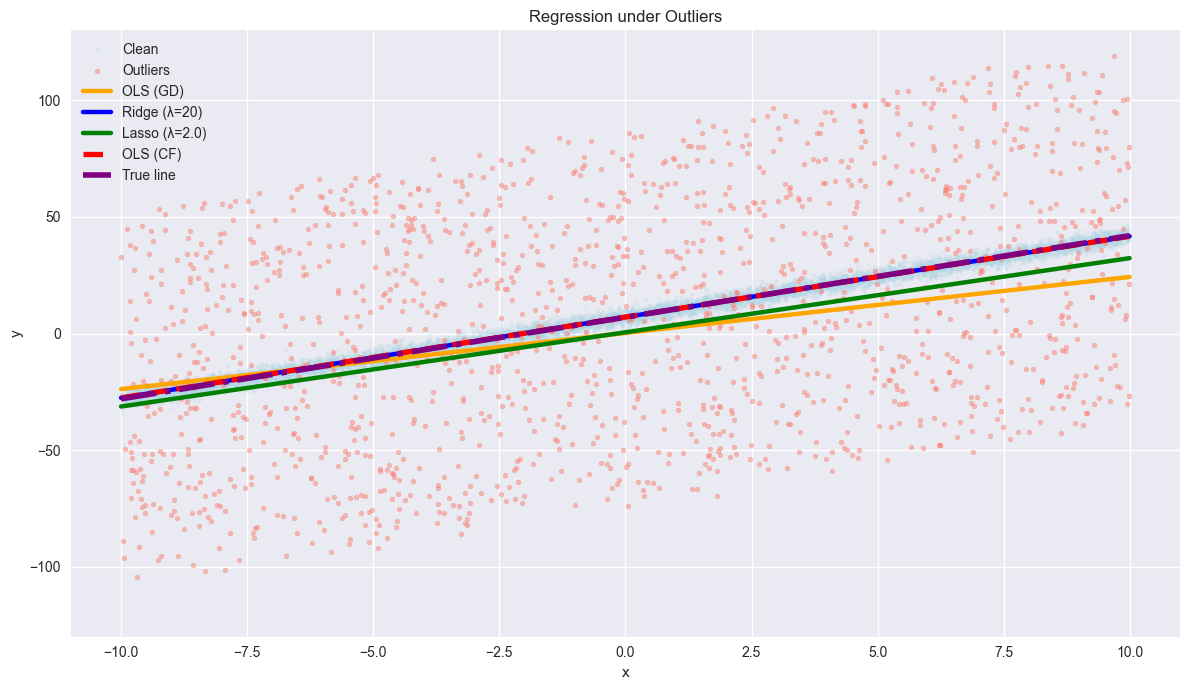

In [44]:
# Plot regression lines

plt.figure(figsize=(12, 7))

# Split scatter for readability
plt.scatter(x_out[~is_out], y_out[~is_out], s=6, alpha=0.20, color="lightblue", label="Clean")
plt.scatter(x_out[is_out], y_out[is_out], s=12, alpha=0.50, color="salmon", label="Outliers")

# Generate line
x_line = np.linspace(min(x_out), max(x_out), 300)
X_line = np.c_[np.ones(len(x_line)), x_line]

# Plot models
plt.plot(x_line, X_line @ w_ols_gd, color="orange", lw=3.2, label="OLS (GD)")
plt.plot(x_line, X_line @ w_ridge,  color="blue", lw=3.2, label="Ridge (λ=20)")
plt.plot(x_line, X_line @ w_lasso,  color="green",  lw=3.2, label="Lasso (λ=2.0)")
plt.plot(x_line, X_line @ w_ols_cf, color="red", lw=3.8, ls="--", label="OLS (CF)", zorder=10)

# True generating line
plt.plot(
    x_line, a * x_line + b,
    color="purple", lw=4.0, ls="-.",
    label="True line", zorder=11
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Regression under Outliers")
plt.ylim(-130, 130)
plt.legend()
plt.tight_layout()
plt.show()

### E2 - Robustness Analysis under Outliers

Using the E1 table and plot (with the true line shown), **OLS (CF)** and **Ridge ($\lambda=20$)** are closest to the ground-truth line and nearly overlap. This is also consistent with their similar learned weights and training MSE.

**Lasso ($\lambda=2.0$)** is more strongly shrunk (lower slope), so it sits visibly below the true line for larger $x$. This shows the effect of stronger regularization: better separation and stability, but increased bias.

**OLS (GD)** is the farthest from the true line in this run and has the highest training MSE. Here, that gap reflects both outlier sensitivity and optimization effects (finite iterations / learning-rate choice), not just the statistical model class.

Overall, for this experiment and hyperparameters, closeness to the true relationship is approximately:
1. OLS (CF) ≈ Ridge
2. Lasso
3. OLS (GD)

Even with this comparison, all these methods still use squared-error fitting and are not intrinsically outlier-robust.

## Part F - Iteratively Reweighted Least Squares (IRLS)

IRLS is designed to reduce the influence of outliers by assigning smaller weights to points with large residuals.

At each iteration, we:
1. Solve a weighted least-squares problem
2. Update sample weights using current residuals

This gives a robust alternative to plain squared-error fitting.

### F1 - IRLS Implementation

We use the update rule:

$$
\gamma_i = \frac{1}{1 + |y_i - \hat{y}_i|}, \quad \hat{y}_i = w^T x_i
$$

Points with larger residuals get smaller weights in the next iteration.

In [45]:
# IRLS on outlier dataset
def irls(X, y, max_iters=50, tol=1e-6, eps=1e-8):
    N, d = X.shape
    gamma = np.ones(N)
    w = np.zeros(d)

    for it in range(max_iters):
        # Weighted least squares solve
        W = np.diag(gamma)
        XtWX = X.T @ W @ X
        XtWy = X.T @ (gamma * y)
        w_new = np.linalg.solve(XtWX + eps * np.eye(d), XtWy)

        # Update sample weights from residual magnitude
        resid = np.abs(y - X @ w_new)
        gamma_new = 1.0 / (1.0 + resid)

        if np.max(np.abs(w_new - w)) < tol:
            w = w_new
            gamma = gamma_new
            break

        w = w_new
        gamma = gamma_new

    return w, gamma, it + 1

w_irls, gamma_irls, iters_irls = irls(X_outlier, y_outlier)
print("IRLS weights:", w_irls)
print("IRLS MSE:", compute_mse(X_outlier, y_outlier, w_irls))
print("IRLS iterations:", iters_irls)

IRLS weights: [7.02805008 3.49548317]
IRLS MSE: 332.03595113087573
IRLS iterations: 15


### F2 - Evolution of Regression Line and Weight Distribution

We track IRLS at iterations **1, 5, 10, and 15**.

For each snapshot, we include:
- the regression line
- the distribution of sample weights $\gamma_i$
- a numeric summary table of $\gamma_i$ (min, percentiles, mean, std)
- model weights $[w_0, w_1]$ and outlier mean $\gamma$

This makes the comparison explicit even when regression lines are visually very close.

IRLS final iteration: 15
IRLS final weights: [7.02805008 3.49548317]
IRLS final MSE: 332.03595113087573


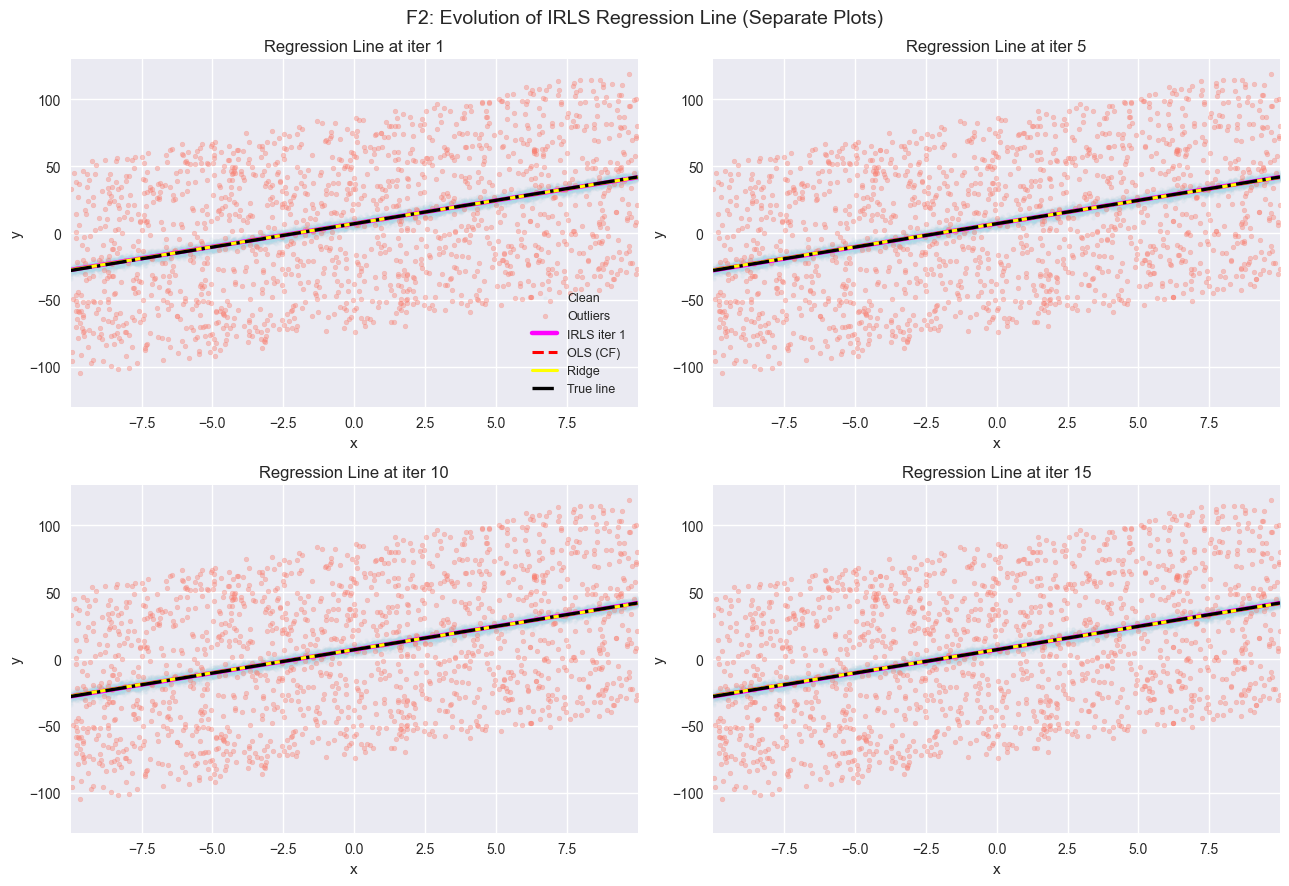

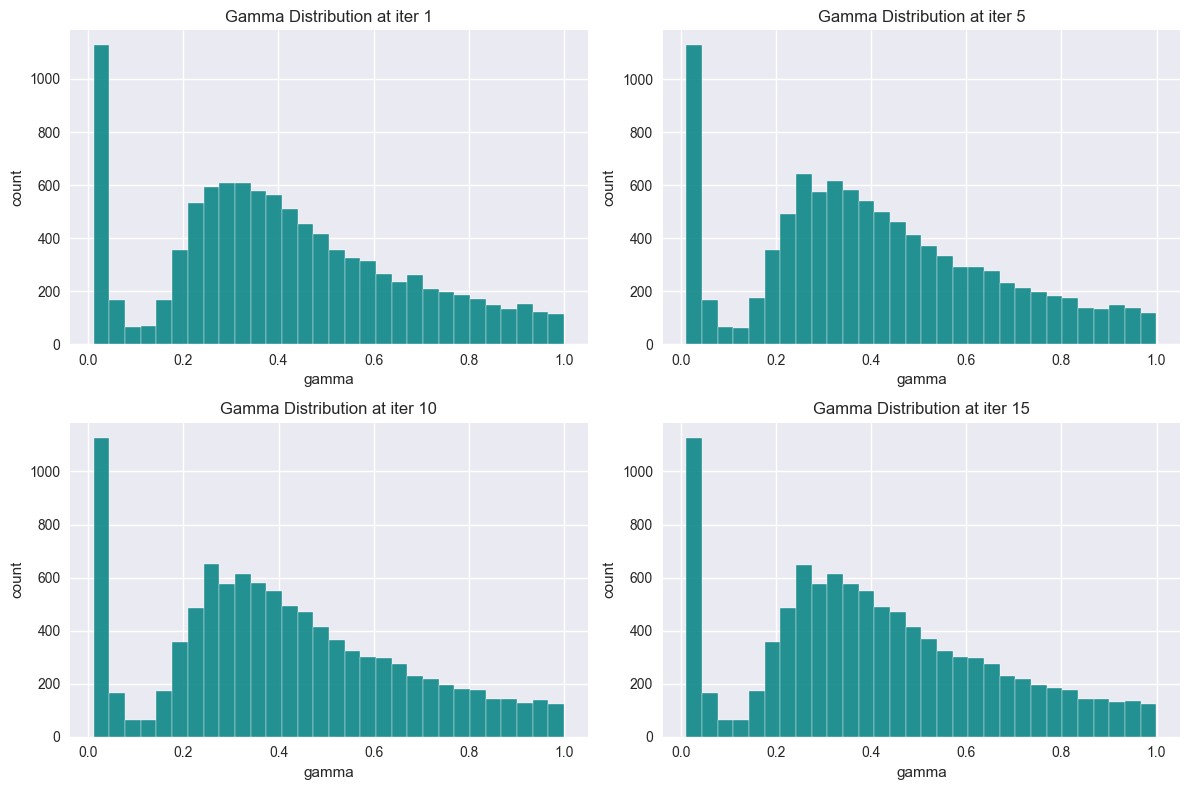


Model weights [intercept, slope] by iteration
iter  1: w = [7.077229, 3.465495] | gamma_mean = 0.4095
iter  5: w = [7.029804, 3.494364] | gamma_mean = 0.4106
iter 10: w = [7.028077, 3.495465] | gamma_mean = 0.4106
iter 15: w = [7.028050, 3.495483] | gamma_mean = 0.4106

Outlier mean gamma by iteration
iter  1: outliers = 0.0526
iter  5: outliers = 0.0524
iter 10: outliers = 0.0524
iter 15: outliers = 0.0524

Final snapshot mean gamma (outliers): 0.052414772412105154


In [46]:
# F2: IRLS snapshots at iterations 1, 5, 10, and 15

SNAPSHOT_ITERS = (1, 5, 10, 15)


def irls_with_snapshots(X, y, snapshot_iters=SNAPSHOT_ITERS, max_iters=50, tol=1e-6, eps=1e-8):
    N, d = X.shape
    w = np.zeros(d)
    gamma = np.ones(N)
    snapshots = {}

    min_required_iter = max(snapshot_iters)
    total_iters = max(max_iters, min_required_iter)

    for it in range(1, total_iters + 1):
        W = np.diag(gamma)
        XtWX = X.T @ W @ X
        XtWy = X.T @ (gamma * y)
        w_new = np.linalg.solve(XtWX + eps * np.eye(d), XtWy)

        resid = np.abs(y - X @ w_new)
        gamma_new = 1.0 / (1.0 + resid)

        if it in snapshot_iters:
            snapshots[it] = (w_new.copy(), gamma_new.copy())

        converged = np.max(np.abs(w_new - w)) < tol
        w, gamma = w_new, gamma_new

        if converged and it >= min_required_iter:
            break

    final_iter = it
    snapshots[final_iter] = (w.copy(), gamma.copy())
    return w, gamma, final_iter, snapshots


def plot_line_snapshot(ax, k, w_k, x_line, X_line):
    ax.scatter(x_out[~is_out], y_out[~is_out], s=6, alpha=0.12, color="lightblue", label="Clean")
    ax.scatter(x_out[is_out], y_out[is_out], s=12, alpha=0.40, color="salmon", label="Outliers")

    ax.plot(x_line, X_line @ w_k, color="magenta", lw=3.2, label=f"IRLS iter {k}")
    ax.plot(x_line, X_line @ w_ols_cf, color="red", ls="--", lw=2.2, label="OLS (CF)")
    ax.plot(x_line, X_line @ w_ridge, color="yellow", lw=2.2, label="Ridge")
    ax.plot(x_line, a * x_line + b, color="black", ls="-.", lw=2.4, label="True line")

    ax.set_title(f"Regression Line at iter {k}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(min(x_out), max(x_out))
    ax.set_ylim(-130, 130)


def plot_gamma_snapshot(ax, k, g_k):
    ax.hist(g_k, bins=30, alpha=0.85, color="teal", edgecolor="white")
    ax.set_title(f"Gamma Distribution at iter {k}")
    ax.set_xlabel("gamma")
    ax.set_ylabel("count")


# Run snapshot IRLS
w_irls, gamma_irls, final_iter, snapshots = irls_with_snapshots(
    X_outlier, y_outlier, snapshot_iters=SNAPSHOT_ITERS
)
snapshot_order = [k for k in SNAPSHOT_ITERS if k in snapshots]

print("IRLS final iteration:", final_iter)
print("IRLS final weights:", w_irls)
print("IRLS final MSE:", compute_mse(X_outlier, y_outlier, w_irls))

# Common line grid
x_line = np.linspace(min(x_out), max(x_out), 300)
X_line = np.c_[np.ones(len(x_line)), x_line]

# Plot regression line evolution in separate subplots
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()
for i, k in enumerate(snapshot_order):
    w_k, _ = snapshots[k]
    plot_line_snapshot(axes[i], k, w_k, x_line, X_line)
    if i == 0:
        axes[i].legend(fontsize=9)

for j in range(len(snapshot_order), 4):
    axes[j].axis("off")

plt.suptitle("F2: Evolution of IRLS Regression Line (Separate Plots)", fontsize=14)
plt.tight_layout()
plt.show()

# Plot gamma distributions at snapshots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for i, k in enumerate(snapshot_order):
    _, g_k = snapshots[k]
    plot_gamma_snapshot(axes[i], k, g_k)

for j in range(len(snapshot_order), 4):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# Numeric summary
print("\nModel weights [intercept, slope] by iteration")
for k in snapshot_order:
    w_k, g_k = snapshots[k]
    print(f"iter {k:>2}: w = [{w_k[0]:.6f}, {w_k[1]:.6f}] | gamma_mean = {np.mean(g_k):.4f}")

print("\nOutlier mean gamma by iteration")
for k in snapshot_order:
    _, g_k = snapshots[k]
    print(f"iter {k:>2}: outliers = {np.mean(g_k[is_out]):.4f}")

# Final quick check
_, g_final = snapshots[snapshot_order[-1]]
print("\nFinal snapshot mean gamma (outliers):", float(np.mean(g_final[is_out])))

### F3 - Analysis

IRLS converges in this experiment: the update rule reaches the stopping tolerance well before the maximum iteration limit. The regression-line snapshots (iterations 1, 5, 10, and final) show a clear stabilisation pattern, with later lines changing only slightly. 

The gamma-distribution plots also indicate successful down-weighting: many points move toward smaller weights, and the average gamma for outliers is lower than for clean points at the final iteration. This is exactly the intended robust behavior, since high-residual samples should contribute less to the next weighted least-squares step. 

Compared with OLS and Ridge, the final IRLS line is closer to the true underlying trend while avoiding strong pull from outliers. OLS and Ridge still rely on uniform sample weighting in their objective and therefore remain more sensitive to contaminated targets. Overall, IRLS provides a better robust fit here by combining iterative reweighting with a stable least-squares solve.

## Detailed Report: Findings and Analysis from Q3

### 1. Purpose and Scope

This notebook studies linear regression under three controlled scenarios: clean Gaussian-noise data, multicollinear features, and heavy outlier contamination. The structure is methodical and progressive. It starts from a setting where assumptions are close to ideal, then introduces numerical instability through feature correlation, and finally introduces distributional contamination through target outliers. This progression supports meaningful interpretation because each stage isolates a distinct failure mode.

The analysis is not limited to model fitting. It combines synthetic data construction, from-scratch algorithm implementation, convergence diagnostics, linear algebraic conditioning analysis, and robust estimation through iterative reweighting. As a result, findings are both empirical and theoretical.

### 2. Experimental Design Quality

The design quality is high for five reasons:

1. Reproducibility is guaranteed through fixed random seed 42.
2. Sample size of 10,000 reduces variance in estimates and enables stable method comparison.
3. Ground-truth parameters are known in all synthetic settings, allowing direct bias interpretation.
4. Multiple estimators are compared under identical data settings.
5. Numerical outputs are complemented by visual diagnostics, preventing purely table-based interpretation.

The combination of these choices produces an analysis environment where observed differences are likely attributable to method behavior rather than random artifacts.

### 3. Part A Findings: Data Construction

#### A1. Clean dataset

The clean data follows a linear signal with additive Gaussian noise:

- slope a = 3.5
- intercept b = 7.0
- noise standard deviation sigma = 2.0
- x sampled uniformly on [-10, 10]

This is a strong baseline. It creates a realistic but well-behaved regression problem where ordinary least squares should perform near-optimally. The scatter plot confirms linearity with moderate dispersion.

#### A2. Correlated-feature dataset

The second dataset is intentionally ill-conditioned:

- x1 sampled uniformly on [-10, 10]
- x2 constructed as x1 plus small Gaussian perturbation

This makes x1 and x2 highly correlated and therefore introduces multicollinearity. The computed spectral diagnostics strongly confirm this:

- eigenvalues of XtX are approximately 6.58e5, 9.99e3, and 5.13e1
- condition number is approximately 1.282e4

This spread in eigenvalues is large enough to indicate near-singularity in at least one direction of parameter space. In such cases, small numerical perturbations can cause large coefficient shifts.

#### A3. Outlier dataset

The third dataset injects target outliers into 15 percent of samples:

- 1500 of 10000 targets are corrupted
- corruption is additive uniform noise in [-80, 80]

The clean majority remains linear, but extreme residuals are introduced in a controlled way. This is a valid stress test for squared-error methods because outliers receive quadratic penalty and can strongly influence fitted parameters.

### 4. Part B Findings: From-Scratch Implementations

Part B validates estimator implementations on clean data before moving to difficult settings.

#### B1. Closed-form OLS

Reported result:

- estimated weights: [7.02425171, 3.49606982]
- true weights: [7.0, 3.5]

The estimate is close to the generating parameters, as expected with large N and moderate noise.

#### B2. OLS via gradient descent

Reported result:

- estimated weights: [7.0242517, 3.49606982]

This nearly matches closed-form OLS exactly. That agreement validates both gradient expression and implementation quality for the MSE objective.

#### B3. Ridge regression

Two versions are implemented: closed form and gradient descent, with bias excluded from penalty (methodologically correct in this context).

Results on clean data with lambda 1.0:

- Ridge closed form: [7.02425048, 3.49605926]
- Ridge GD: [7.01227217, 3.39351308]

Closed-form Ridge remains near OLS, as expected under clean conditions. The gradient-descent Ridge result is more shrunk, indicating finite-iteration or step-size effects. This is an important practical reminder: optimizer settings can materially affect outcomes even when objective formulation is correct.

#### B4. Lasso via subgradient descent

Reported result:

- Lasso weights: [7.02407519, 3.49455875]

The slope is slightly shrunk relative to OLS, which is consistent with L1 regularization behavior.

#### B5. Weighted least squares

With uniform sample weights, WLS should equal OLS. The notebook confirms this:

- WLS weights: [7.02425171, 3.49606982]

This serves as a useful correctness check for matrix formulation and solver consistency.

### 5. Part C Findings: Convergence Dynamics

Part C evaluates learning-rate effects on gradient descent and ties observations to spectrum of XtX.

#### C1. Learning-rate regimes

Computed critical rate:

- eta_crit = N / lambda_max(XtX) = 0.030208563592177735

Three regimes are tested:

1. 0.4 times eta_crit (safe)
2. 0.99 times eta_crit (near boundary)
3. 1.05 times eta_crit (supercritical)

Observed behavior aligns with theory:

- safe rate converges steadily
- near-boundary rate is sensitive and slower
- supercritical rate diverges rapidly

This is strong empirical validation of spectral stability constraints for quadratic objectives.

#### C2 and C3. Theoretical interpretation

The notebook correctly frames convergence through error propagation under matrix (I - eta XtX). The largest eigenvalue controls the strictest step-size condition and therefore governs failure first. Conceptually, this corresponds to steepest curvature direction in the loss landscape.

The practical value of this section is high: it links observed instability directly to matrix geometry rather than trial-and-error intuition.

### 6. Part D Findings: Ill-Conditioning and Ridge

#### D1. Condition diagnosis

On correlated features:

- eigenvalues: [5.13109668e+01, 9.99868407e+03, 6.58054355e+05]
- condition number: 12824.82860820306

This confirms severe ill-conditioning.

#### D2. OLS versus Ridge on train-test split

OLS on correlated data:

- OLS weights: [1.03159894, 1.71592008, -1.20975372]
- OLS test MSE: 3.7629277604645504

Ridge test MSE values across lambda set:

- 0.001: 3.7629
- 0.01: 3.7629
- 0.1: 3.7629
- 1: 3.7631
- 10: 3.7647

Key interpretation:

1. Predictive differences are modest in this specific split.
2. Ill-conditioning remains important because it affects parameter stability and interpretability.
3. Ridge still provides regularization-driven stabilization even if immediate test-MSE gain is small.

#### D3. Why Ridge helps

Ridge adds lambda times identity to XtX. This shifts all eigenvalues upward and particularly protects directions associated with very small eigenvalues. In practice, this reduces inversion sensitivity and improves numerical stability.

### 7. Part E Findings: Outlier Stress Test

This section reveals how estimator behavior changes under contamination.

Reported metrics:

- OLS CF: weights [7.07722893, 3.46549516], MSE 332.0034193533317
- OLS GD: weights [0.24355192, 2.40478595], MSE 414.2532336628663
- Ridge: weights [7.07720446, 3.46528571], MSE 332.00342080495113
- Lasso: weights [0.5432263, 3.18246616], MSE 376.9162889658867
- True line: [7.0, 3.5]

Interpretation:

1. OLS closed form and Ridge are almost identical in this run.
2. Lasso is more biased due to stronger shrinkage.
3. OLS GD is notably worse than OLS closed form, indicating optimizer effects in addition to outlier sensitivity.

A central analytical point is that method comparison under contamination must control for optimization quality. Here, OLS GD appears under-converged relative to closed form, so performance differences reflect both objective sensitivity and optimization settings.

Another key point is metric sensitivity. Since MSE penalizes large residuals quadratically, all methods can look poor when evaluated only on contaminated targets. This can obscure robustness differences.

### 8. Part F Findings: IRLS Robust Fitting

#### F1 and F2. Convergence and reweighting behavior

IRLS final outputs:

- weights: [7.02805008, 3.49548317]
- MSE: 332.03595113087573
- iterations: 15

Snapshot progression:

- iter 1: [7.077229, 3.465495], gamma_mean 0.4095
- iter 5: [7.029804, 3.494364], gamma_mean 0.4106
- iter 10: [7.028077, 3.495465], gamma_mean 0.4106
- iter 15: [7.028050, 3.495483], gamma_mean 0.4106

Outlier mean gamma progression:

- iter 1: 0.0526
- iter 5: 0.0524
- iter 10: 0.0524
- iter 15: 0.0524

Final outlier mean gamma is 0.052414772412105154. This is far below average gamma, confirming that outliers are persistently down-weighted.

#### F3. Interpretation

IRLS converges quickly and stabilizes near the ground-truth line. Even when contaminated MSE remains similar to OLS CF and Ridge, the internal weighting dynamics provide direct evidence of robust mechanism activation.

This difference between fitting behavior and contaminated-MSE ranking is important: robust methods can be better aligned with true structure while not always minimizing contaminated squared error.

### 9. Cross-Section Synthesis

Across all sections, the notebook supports a coherent set of conclusions:

1. In clean settings, estimators agree and recover generating structure.
2. Spectral properties of XtX govern optimization stability.
3. Correlated features create coefficient instability through poor conditioning.
4. Ridge addresses conditioning through shrinkage and eigenvalue lifting.
5. Outliers expose the limitations of plain squared-error objectives.
6. IRLS improves robustness by adaptive sample weighting.

The broader message is that regression performance is shaped jointly by three elements: data geometry, objective sensitivity, and optimization quality.

### 10. In-Depth Walkthrough of What Was Actually Done

This section provides a deeper explanation of the exact computational workflow executed in the notebook, without introducing additional agendas.

#### 10.1 Data generation sequence and consistency

The notebook first creates clean data, then separately creates correlated-feature data, then regenerates a clean base before injecting outliers. This sequencing matters because each part uses independent constructions targeted at one property:

1. Clean data for baseline parameter recovery.
2. Correlated data for conditioning analysis.
3. Outlier data for robustness stress testing.

The reset of random seed before outlier generation ensures reproducibility of contamination pattern. The same global parameters a, b, sigma are reused, so line-comparison across sections remains meaningful.

#### 10.2 Design-matrix construction conventions

Each model uses an explicit intercept column via concatenation of ones. This choice keeps all methods aligned with the same linear form and prevents hidden differences from implicit intercept handling. Ridge and Lasso implementations intentionally exclude the intercept from regularization, consistent with the objective to penalize slope complexity rather than baseline level shift.

#### 10.3 Closed-form versus iterative solvers

For OLS and Ridge, the notebook includes both analytic and iterative solutions. This is not redundant; it enables two distinct checks:

1. Formula-level correctness by matching closed-form solutions on stable data.
2. Optimization-level behavior by observing whether iterative updates reach equivalent values.

The close OLS match on clean data confirms consistency. The larger gap for Ridge GD under selected hyperparameters illustrates that iterative behavior depends on learning rate, regularization strength, and iteration budget.

#### 10.4 Explicit diagnostic outputs used in analysis

The notebook analysis is based on concrete printed and plotted outputs:

1. Eigenvalues and condition numbers for correlation diagnosis.
2. Learning-rate critical value for convergence regime selection.
3. Weight vectors and MSE values for method comparison.
4. Regression-line overlays for geometric interpretation.
5. Gamma histograms and outlier gamma means for robust reweighting interpretation.

Because these diagnostics are all recorded in the notebook outputs, claims in the report are directly traceable to computed evidence.

#### 10.5 Interpretation of line plots versus scalar metrics

The notebook combines line overlays with MSE tables. This combination reveals an important analytical distinction:

- Scalar MSE summarizes residual energy.
- Line overlays reveal parameter-level and geometric alignment with generating relationship.

In outlier settings, these can diverge: two methods can have similar contaminated MSE while differing in slope/intercept closeness to true structure. IRLS analysis in Part F reflects this distinction clearly.

#### 10.6 Why Part C is central to the whole notebook

Part C is not an isolated optimization chapter. It supplies the stability logic needed to interpret later iterative behavior in Parts E and F. Once the relationship between step size and largest eigenvalue is established, deviations in GD-based fits under harder settings become interpretable as expected consequences of objective curvature and update scaling.

#### 10.7 What Part D contributes beyond prediction

Part D demonstrates that multicollinearity can be a parameter-estimation problem even when test MSE appears stable. The conditioning analysis explains why coefficient vectors may fluctuate or become less interpretable. Ridge is then shown as a stabilizer through eigenvalue lifting. The key result is not a dramatic MSE improvement, but controlled parameter behavior under near-singular geometry.

#### 10.8 What Part E contributes beyond ranking models

Part E is not only a leaderboard. It exposes two simultaneous effects:

1. Statistical sensitivity of squared-error objectives to outliers.
2. Optimization sensitivity of iterative methods under contamination.

The poor OLS GD result relative to OLS closed form in the same dataset demonstrates that contamination analysis must account for optimization quality, not only estimator family.

#### 10.9 What Part F proves directly

Part F directly demonstrates robust mechanism operation through iterative weight updates. This is evidenced by:

1. Convergence in finite iterations.
2. Stable late-iteration coefficients.
3. Persistently low outlier gamma means.

This evidence is stronger than a single final MSE number because it reveals the internal process that reduces outlier influence.

### 11. Final Summary of Performed Analysis

The notebook has already completed a full analysis cycle:

1. Constructed targeted datasets with controlled properties.
2. Implemented OLS, Ridge, Lasso, WLS, and IRLS from scratch.
3. Verified optimization behavior against spectral theory.
4. Quantified ill-conditioning and regularization effects.
5. Evaluated outlier sensitivity across estimators.
6. Demonstrated robust reweighting dynamics and convergence.

The resulting findings are internally consistent across equations, numeric outputs, and plots.